---
title: "The Price is Right: A Projective Geometry Analysis for Optimal Goaltender Positioning in Hockey"
author: "Malakai Harianto"
date: "2026-09-01"
date-format: "MMMM YYYY"
geometry: "margin=1in"
fontsize: 11pt
documentclass: article
bibliography: references.bib
biblio-style: plain
linkcolor: black
urlcolor: black
citecolor: black
toccolor: black
toc: true
number-sections: true
abstract: |
  abstract idk
format:
  pdf:
    pdf-engine: xelatex
execute:
  echo: false
  warning: false
---

In [46]:
import model
import numpy as np
import matplotlib.pyplot as plt

%reload_ext autoreload
%autoreload 2

<unknown>:622: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:623: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:622: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:623: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:622: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:623: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<unknown>:622: SyntaxWarning

\newpage
# Introduction
## Motivation and Theory
The sport of ice hockey (hockey) has undergone significant development in the past two decades, with players skating faster, hitting harder, and shooting more accurately than any point in history [@found2016goalmetrics]. Reflecting on National Hockey League (NHL) gameplay footage from before the mid-to-late 1990s, a particular evolution can be noted in the techniques of the positioning and blocking of goaltenders.

Glenn Hall quietly revolutionised hockey goaltending as early as the 1950s, by dropping his pads behind his stick to block pucks aimed between his legs, in what was the first case of a technique which is now referred to as the "butterfly". Another goaltender, Patrick Roy, pioneered and developed on this method of goaltending throughout the 1980s to 2000s, eventually popularising it to the level of near universal adoption in the NHL [@evans2022roy]. Nowadays, this technique is standard throughout every level of hockey, from recreational leagues to the highest level professionals, and goaltenders have the potential to be better than at any point in history because of it.

The strength of this technique, however, is not without drawbacks. While in the butterfly, the steel of a goaltenders skate does not touch the ice at all times. This produces a dichotomy: An aggressive goaltender near the front of the crease minimises the effective net area by maximising their projection over the net, but leaves them prone to backdoor or passing shot attempts as mobility is more difficult. Conversely, a goaltender sitting at the goal line will be able to move from end-to-end significantly faster to block these indirect shots, but leaves plenty of exposed effective net area for the shooter. 

This positioning is a quiet trade-off which is calculated without thinking in the mind of an experienced goalie during every moment of play. Goalies with high save percentages (sv%), are able to balance this "crease aggression", and effectively balance between prioritising stopping direct shots or backdoor passes. Anecdotally, goalies with low sv% tend therefore to be punished more for "overextension", or positioning too aggressively, than passively. 


## Research
In the intuitive viewing perspective, it is not unreasonable to expect that a goaltender sitting at their near defensive line likely suffers similar disadvantages as if they were sitting at the centre line. This occurs since they are both effectively act like the same distance from the goal for practical transition, both are impractical for blocking passing shot opportunities if it is needed, despite a physical distance of 6 to 7 metres between them.  

Furthermore, shots are released from a continuous neighbourhood of coordinates rather than individual point coordinates. Therefore, puck release is modelled at locations as a spatial distribution $P \sim N(\vec{p}_0, {\Sigma})$ centred around a play spot $\vec{p}_0$ with spread $\sigma=\begin{bmatrix}\sigma_x^2&0\\0&\sigma_y^2\end{bmatrix}$. Hence, it was hypothesised that the goaltender depth $d_g$ gives diminishing returns in coverage beyond a certain threshold, while significantly increasing vulnerability to dynamic shooting opportunities.

Three core research questions guide this study:

1. **How does the effective uncovered net surface area $A_{eff}$ scale as a function of a distribution of puck positions $P\sim N(\vec{p}_0,\Sigma)$ and goaltender depth $d_g$?** 

2. **What is the optimal depth $d_{g}$ required to achieve the maximised expected blocking ($E[A_{\text{eff}}]$) for direct shots with release uncertainty?**

3. **At what depth does the probability of a late recovery $P_{late}=P(\delta t>0)$ exceed an acceptable risk threshold across common passing lanes?**

## Aim
This study aims to construct a 3D projective geometry model which calculates the expected effective net exposure across shots released from typical neighbourhoods, and formalise a mathematical understanding of crease depth optimisation.

As a consequence of this, the study also seeks to find optimal theoretical goalie positioning standards which can be used for development of coaching analytics, and potentially contribute to mathematical analyses of goaltending theory and broader sports analytics in a rapidly evolving goaltender strategy landscape.

# Methodology
## Domain and Geometric Parameters
### Coordinate System Convention
In order to model the projection of the goaltender unto the effective shooting area of the net, the rink is parameterised according to a standard cartesian coordinate system $C_{rink}=(x,y,z)^T \in\mathbb{R}^3$, from the goal line outwards. All figures concerning measurements of the rink and goal are taken from @nhl2024rulebook. 

- The $x$ axis represents the transverse direction across the width of the rink, where $x\in[-12.95,12.95]\text{m}$. 

- The $y$ axis represents the forward distance extending into the offensive zone from the goal line, where $y>0$. 

- The $z$ axis represents the elevation above the ice surface $z\ge0$

- As a consequence to these conventions, the origin $(0,0,0)^T$ is situated at ice level directly at the midpoint of the goal line. 

### Goal Frame and Crease Boundaries
The goal mouth is modelled as a rectangular plane resting perpendicular to the surface of the ice sharing the boundary line $y,z=0,0$, with $A_{net}$ given by
$$A_{\text{net}} = \left\{ (x, z) \in \mathbb{R}^2 \;\middle|\; -\frac{W_{net}}{2} \le x \le \frac{W_{net}}{2},\; 0 \le z \le H_{net} \right\}$$
And the standard NHL net width $W_{net}=1.83\text{m}$, and height $H_{net}=1.22\text{m}$. The effective crease will be taken as a semi circle of radius $R_{crease}=1.83\text{m}$, to account for the aggression which this study focuses on.

### Static Goaltender Representation
The goaltender will be modelled as a rectangular plane oriented orthogonally to the puck - centre-goal line of sight at initial start time $t_0$, where @evans2022roy aids us to getting the following approximations.

- The width of the goaltender is taken to be $W_g=1.15\text{m}$ and height $H_g=0.95\text{m}$, representing an idealised butterfly block including blocker and glove save ranges. 

- The goaltender will be positioned with their centre at distance $d_g$ from the centre of the goal, on the puck - centre-goal line of sight.

## Perspective Projection
### Puck Vector and Shooting Angle
Let the puck location at ice level $z=0$ be represented by the position vector
$$
\vec{p}=(x_p,y_p,0)^T
$$
The shooting distance from the goal line midpoint at ice level $(0,0,0)^T$ to $\vec{p}$ is given by $D_s=\sqrt{x_p^2 + y_p^2}$, and the shot angle relative to the centre line $x=0$ is given by
$$\theta = \arctan\left(\frac{x_p}{y_p}\right) \in \left(-\frac{\pi}{2}, \frac{\pi}{2}\right)$$
Then the unit line of sight direction vector from the goal line midpoint at ice level to the puck is $\hat{u}=(\sin(\theta),\cos(\theta),0)^T$. Also define an orthogonal lateral unit vector to $\hat{u}$ which will be used to build the goaltender in a following subsection, $\hat{n}=(\cos(\theta),-\sin(\theta),0)^T$

### Effective Apparent Net Area as Function of Angle
Notice that the physical goal frame in 3D space consists of a flat opening $A_{net}$ defined on $y,z=0,0$ bounded on the left and right posts by $B_{L}=(-\frac{W}{2},0,0)^T,B_{R}=(\frac{W}{2},0,0)^T$ respectively, and the crossbar at height $z=H$.

From the shooter's point of view, the apparent lateral width of the goal is a function of the angle $\theta$ relative to the centre of the goal. This apparent net width is given by
$$W_\theta=W\cos(\theta)$$
And therefore, the shooter has the full projected net area $A_\theta$ given by
$$A_\theta=W(\theta)\cdot H= W H \cos(\theta)$$
Then, as $\theta\to\pm\frac{\pi}{2}$, where the shooter is parallel to the goal line, $W_\theta \to 0$ and $A_\theta \to 0$.

### Goaltender Position and Squareness to Puck
The goaltender's centre $\vec{G}$ is positioned at crease depth $d_g \in [0, R_{crease})$ along the principal puck ray ($\vec{p}_0$)
$$\vec{G}(d_g) = d_g \hat{u} + (0,0, \frac{H_g}{2})^T= ( d_g \sin(\theta), d_g \cos(\theta), \frac{H_g}{2})$$

The goalie's plane remains perpendicular to the nominal puck line of sight ($\vec{p}_0 - \vec{G}$), and so the outline is defined by four corner vertices $\vec{v}_1,\vec{v}_2,\vec{v}_3,\vec{v}_4$ spanning width $\frac{W_g}{2}$ along the orthogonal vector $\hat{n}$ in either direction and height $H_g$ along the vertical $\hat{z}$. Accounting for the distribution of releases, the goaltender will have slight angle misalignments for a portion of incoming shots.

$$
\vec{v}_{1,2} = (d_g \sin(\theta), d_g \cos(\theta),0)^T \pm \frac{W_g}{2} ( \cos(\theta) ,-\sin(\theta), 0 )^T 
$$

$$
\vec{v}_{3,4} = (d_g \sin(\theta), d_g \cos(\theta),H_g)^T \pm \frac{W_g}{2} ( \cos(\theta) ,-\sin(\theta), 0 )^T 
$$

Where $\vec{v}_{1,2}$ are the bottom right and left corners, and $\vec{v}_{3,4}$ are the top right and left corners.

### Puck Perspective Projection
Every ray originating from the puck $\vec{p} = (x_p, y_p, 0)^T$ through any vertex $\vec{v}_i = (x_{v,i}, y_{v,i}, z_{v,i})^T$ can be parameterised by some $t \ge 0$, which is given by
$$\vec{r}_i(t) = \vec{p} + t (\vec{v}_i - \vec{p})$$
Letting $y=0$ and finding some $t^*$ at that point, which is the point which the puck reaches the goal line boundary, 
$$y_p + t^*(y_{v,i} - y_p) = 0 \implies t^* = \frac{y_p}{y_p - y_{v,i}}$$
Substituting $t^*$ into the $x$ and $z$ components gives the projected coordinates $(x_{{proj}, i}, z_{{proj}, i})$ at $y = 0$

$$x_{{proj}, i} = x_p - \left( \frac{y_p}{y_p - y_{v,i}} \right) (x_p - x_{v,i}) = \frac{x_{v,i} y_p - x_p y_{v,i}}{y_p - y_{v,i}}$$

$$z_{{proj}, i} = \left( \frac{y_p}{y_p - y_{v,i}} \right) z_{v,i}$$


### Effective Exposed Area
The projected vertices define a quadrilateral region on the target plane $(x, z)$. 

The effective uncovered net surface area $A_{eff}(d_g; \vec{p})$ is computed as the geometric difference between the physical net aperture ${A}_{net}$ and the projected silhouette ${p}_{proj}$:
$$
A_{eff}(d_g; \vec{P}) = \iint_{{A}_{net}- {p}_{{proj}}} dx\,dz
$$

The normalised fractional visual blocking metric $\mu(d_g; \vec{p})$ relative to the apparent angular opening is therefore
$$
\mu(d_g; \vec{p}) = 1 - \frac{A_{{eff}}(d_g; \vec{p})}{A_\theta} = 1 - \frac{A_{{eff}}(d_g; \vec{p})}{W H \cos(\theta)}
$$
where $\mu = 1.0$ ($100\%$) denotes complete geometric occlusion of the goal mouth.

## Dynamic Mobility Formulation 
### Puck Transit Time
Assuming a constant pass velocity $v_{pass}$, the time required for the puck to traverse between surface level points $\vec{p}_1=(x_{p1},y_{p1})$ and $\vec{p}_2=(x_{p2},y_{p2})$ can be calculated by
$$
\Delta t_{pass} = \frac{\|\vec{p}_2 - \vec{p}_1\|}{v_{pass}} = \frac{\sqrt{(x_{p2} - x_{p1})^2 + (y_{p2} - y_{p1})^2}}{v_{pass}}
$$

### Goaltender Recovery Kinematics
Let the goaltender's initial optimal position be $\vec{G}_1 = \vec{G}(d_g; \vec{p}_1)$ and target post-pass position be $\vec{G}_2 = \vec{G}(d_g; \vec{p}_2)$ at a constant crease depth $d_g$. The distance the goaltender must travel across the crease is
$$
\Delta s_g(d_g) = \|\vec{G}_2 - \vec{G}_1\| = d_g \sqrt{(\sin(\theta_2) - \sin(\theta_1))^2 + (\cos(\theta_2) - \cos(\theta_1))^2} = 2 d_g \sin\left(\frac{|\theta_2 - \theta_1|}{2}\right)
$$

Then, the total recovery time required for the goaltender to re-establish squareness at $\vec{G}_2$ incorporates human reaction time $t_{react}$ and constant lateral slide velocity $v_{slide}$
$$
\Delta t_{goalie}(d_g) = t_{react} + \frac{\Delta s_g(d_g)}{v_{slide}}
$$

### Net Recovery Exposure
The goaltender recovery time is defined as
$$
\delta t(d_g) = \max\left(0,\, \Delta t_{goalie}(d_g) - \Delta t_{pass}\right)
$$
Note that $\delta t(d_g)$ is a continuous random variable since $\vec{p}_2$ is distributed across a spatial region. When $\delta t(d_g) > 0$, the receiving shooter at $\vec{p}_2$ faces an unrecovered net aperture for a duration of $\delta t(d_g)$, during which the effective exposed area is the baseline area $A(\theta_2) = W H \cos(\theta_2)$.

### Parameter Constants
Hence, standard $v_{pass},v_{slide},t_{react}$ will be used from empirical sports biomechanics and tracking literature [@jain2015reactiontime]

* Mean puck pass velocity: $v_{pass} = 25.0\,\text{ms}^{-1}$
  
* Lateral butterfly slide velocity: $v_{slide} = 3.5\,\text{ms}^{-1}$
  
* Visual-motor reaction time: $t_{react} = 2\times 10^{-1}\,\text{s}$

## Optimisation
### Static Case
In a direct shot, that is a shot directly from some $\vec{p}$ towards the goal, where any particular $\vec{p}$ is sampled from a distribution $P\sim N(\vec{p}_0,\sigma)$, where $\sigma=\begin{bmatrix}\sigma_x^2&0\\0&\sigma_y^2\end{bmatrix}$. The goaltender coverage only depends on the principal position of the puck $\vec{p}_0$ and the azimuth angle $\theta$ from the centre of the goal. 

That is to say, optimising the goaltender position is the same as minimising the expected effective area
$$d^*_g=\arg\min_{d_g\in[0,R_{crease}]} E_{\vec{p}}[A_{eff}(d_g;\vec{p})]$$

Some common shot types which will be evaluated, among others, will be modelled as follows

- *Low slot*: $\vec{p}_0=(0,5)$

- *High slot*: $\vec{p}_0=(0,10)$

- *Face-off dot*: $\vec{p}_0=(6.7,6)\implies \theta\approx48^{\circ}$

- *Goal line corner*: $\vec{p}_0=(10,2)\implies \theta\approx79^{\circ}$

### Dynamic Case
In the dynamic case, which is a passing play from $\vec{p}_1\to\vec{p}_2$, the objective of the model is to find the optimal $d^*_g$ for maximal feasibility in saving the shot which comes from $\vec{p}_2$ while minimising vulnerability at $\vec{p}_1$.

Using the equation derived for $\delta t (d_g)$, the optimal goaltender depth in the dynamic case $d^*_g$ is 
$$d^*_g=\sup\{d_g\ge 0 | \delta t (d_g)=0 \}$$

The pass reception in reality does not occur at a single point, but across a neighbourhood. Define the receiving puck location as a random variable ${P}_2 \sim \mathcal{N}(\vec{p}_{0,2}, \Sigma_2)$ centred at the principal target vector $\vec{p}_{0,2}$. Consequently, the puck transit time $\Delta t_{pass}$ and required recovery distance $\Delta s_g$ become continuous random variables.

Similarly to the static case, some common passing shot types will be modelled as follows

- *Seam pass*: $\vec{p}_1=(-5,7),\vec{p}_2=(5,7)$

- *Goal line feed*: $\vec{p}_1=(4,1),\vec{p}_2=(0,5)$

- *Breakaway one-timer*: $\vec{p}_1=(0,14),\vec{p}_2=(6.7,6)$

# Results

## Static Uncertainty Analysis

### Baseline Exposure Contours
Before observing the model for more complex and stochastic analyses of goaltender position optimisation, it helps to first establish a geometric baseline and intuition to the model by plotting baseline exposure contours given a shot released only from $\vec{p}_0=(x,y)$. This provides what a line of sight vulnerability field looks like when a goaltender commits to a depth $d_g$ to a specific target, and a basis for understanding the stochastic models to follow. 

This also verifies that the models are capable of resolving shadows of effectively $0$ exposed net area along the ray connecting the net origin to $\vec{p}_0$, and that the coordinate transforms and physical domain bounds make some sense.

Therefore, four figures are drawn corresponding to the four nominal static cases, and gives a broad overview of the effects of moving $\vec{p}_0$ on the exposed area contours across the rink.

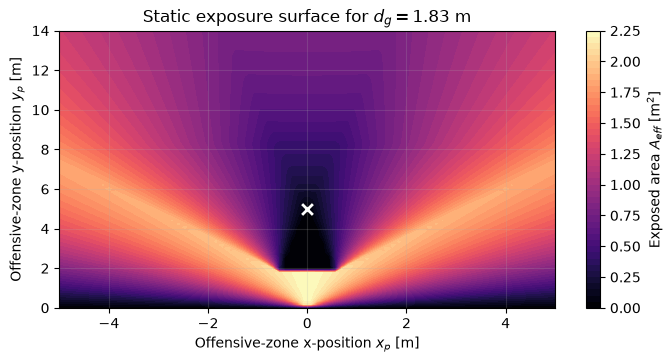

In [47]:
#| label: fig-exposure-surface-1
#| fig-cap: "Static exposure surface for $d_g = 1.83$ m, Low Slot shot $\\vec{p}_0 = (0, 5)$ m."
#| fig-width: 4.5
#| fig-height: 3.6
#| fig-pos: "H"
#| fig-align: "center"

fig, ax = model.plot_exposure_contour(x_grid = np.linspace(-5.0, 5.0, 80), p0=(0,5))

In @fig-exposure-surface-1, observe that long the nominal shooting line, the perspective projection of the stance silhouette completely eclipses the net mouth, generating a continuous corridor of minimal exposure (where $A_{eff}\approx 0.00m^2$). At this aggressive depth, the goaltender covers a larger solid angle than the net opening for all on-axis slot distances. Also, observe that the transition out of the central shadow is abrupt. A lateral departure of merely $Δx=±1.0m$ exposes substantial portions of the posts where $A_{eff}>0.80m^2$, and climbs rapidly towards a practically uncovered net opening along wider angles. This provides some visual intuition of the fragility of committing directly to a shot at $\vec{p}_0$, since relatively small deviations in shots can dispropostionately penalise a static goaltender.

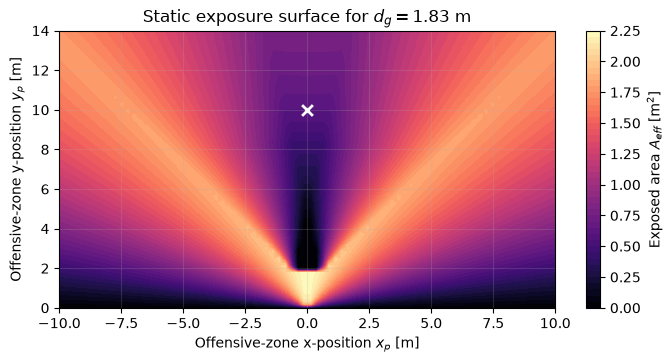

In [48]:
#| label: fig-exposure-surface-2
#| fig-cap: "Static exposure surface for $d_g=1.83m$, *High Slot* shot $\\vec{p}_0=(0,10)$"
#| fig-width: 4.5
#| fig-height: 3.6
#| fig-pos: "H"
#| fig-align: "center"

fig, ax = model.plot_exposure_contour(p0=(0,10))

Very similarly to @fig-exposure-surface-1, there is a clear yet slim line of blocking directly between the goaltender and the puck, but due to the increased distance between the puck and the net, even the most aggressive goaltender at $d_g=1.83m$ is still unable to completely cover the net with their projection. However, since even at this optimal depth there is already a decent exposure, visible on @fig-exposure-surface-2, lateral variations do not impact the goaltender as disproportionately as the first case, and so the marginal penalty for angular tracking error is reduced. 

Generally, in higher distance shot scenarios, the goaltender’s projected silhouette shrinks on the goal plane, unable to span the full vertical extent of the crossbar even when perfectly centered. The continuous exposure of $A_{eff}\approx 0.00m^2$ vanishes at around $y_p\approx 6.0m$, after which some portion of the upper corners will be permanently exposed, and the trade off appears to be the less aggressive lateral gradient of exposed area.

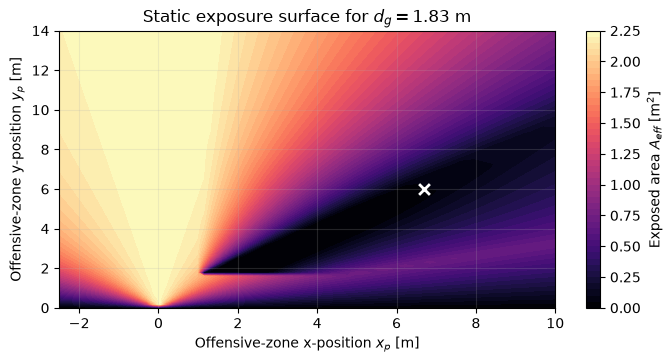

In [49]:
#| label: fig-exposure-surface-3
#| fig-cap: "Static exposure surface for $d_g=1.83m$, *Face-off Dot* shot $\\vec{p}_0=(6.7,6)$"
#| fig-width: 4.5
#| fig-height: 3.6
#| fig-pos: "H"
#| fig-align: "center"

fig, ax = model.plot_exposure_contour(x_grid = np.linspace(-2.5, 10.0, 80), p0=(6.7,6))


writeup about above ^

this is the plot for goal line corner


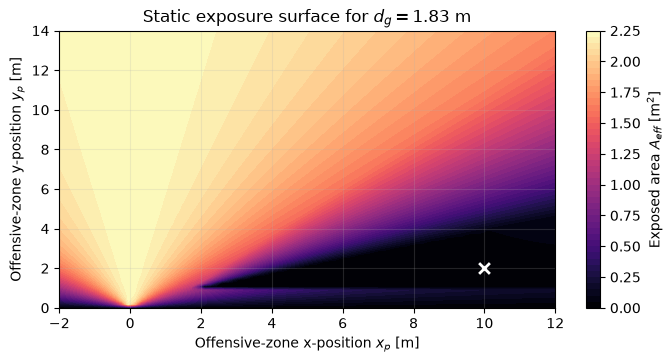

In [50]:
#| label: fig-exposure-surface-4
#| fig-cap: "Static exposure surface for $d_g=0.70m$, *Goal Line* shot $\\vec{p}_0=(10,2)$"
#| fig-width: 4.5
#| fig-height: 3.6
#| fig-pos: "H"
#| fig-align: "center"

fig, ax = model.plot_exposure_contour(x_grid = np.linspace(-2.0, 12.0, 80), p0=(10,2))


writeup about above ^


### Release Cloud Exposure and Goal Plane Heatmap
Extending on the above, note that if there are areas which are non-zero near the goal ...


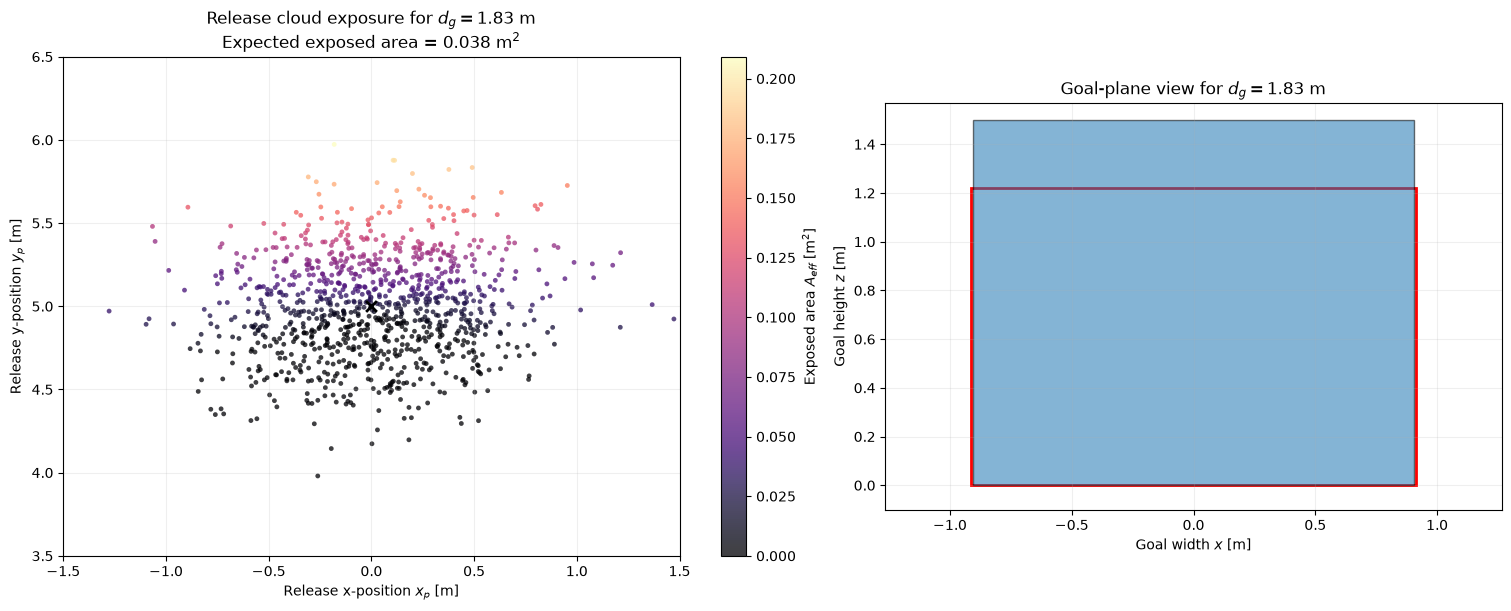

In [51]:
#| label: fig-static-dual-1
#| fig-cap: "Stochastic release analysis for a Low Slot shot $\\vec{p}_0 = (0, 5)$ m at $d_g = 1.83$ m. (a) Release cloud exposure on the ice plane. (b) Goal-plane perspective occlusion."
#| out-width: "100%"
#| fig-pos: "H"
#| fig-align: "center"

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(15, 6),
    constrained_layout=True
)

model.plot_release_cloud_exposure(
    p0=(0.0, 5.0),
    ax=ax1
)

model.plot_goal_plane_heatmap(
    p0=(0.0, 5.0),
    ax=ax2
)

plt.show()

writeup about above ^


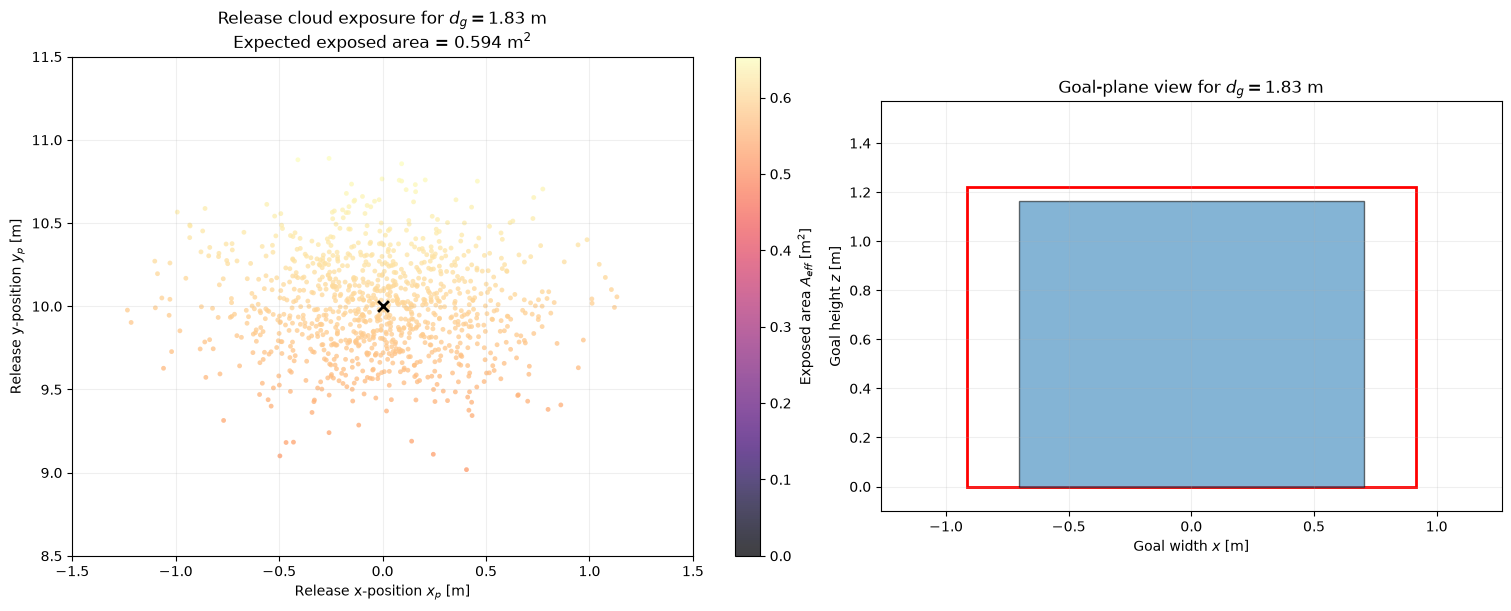

In [52]:
#| label: fig-static-dual-2
#| fig-cap: "Stochastic release analysis for a High Slot shot $\\vec{p}_0 = (0, 10)$ m at $d_g = 1.83$ m. (a) Release cloud exposure on the ice plane. (b) Goal-plane perspective occlusion."
#| out-width: "100%"
#| fig-pos: "H"
#| fig-align: "center"

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(15, 6),
    constrained_layout=True
)

model.plot_release_cloud_exposure(
    p0=(0.0, 10.0),
    ax=ax1
)

model.plot_goal_plane_heatmap(
    p0=(0.0, 10.0),
    ax=ax2
)

plt.show()

writeup about above ^


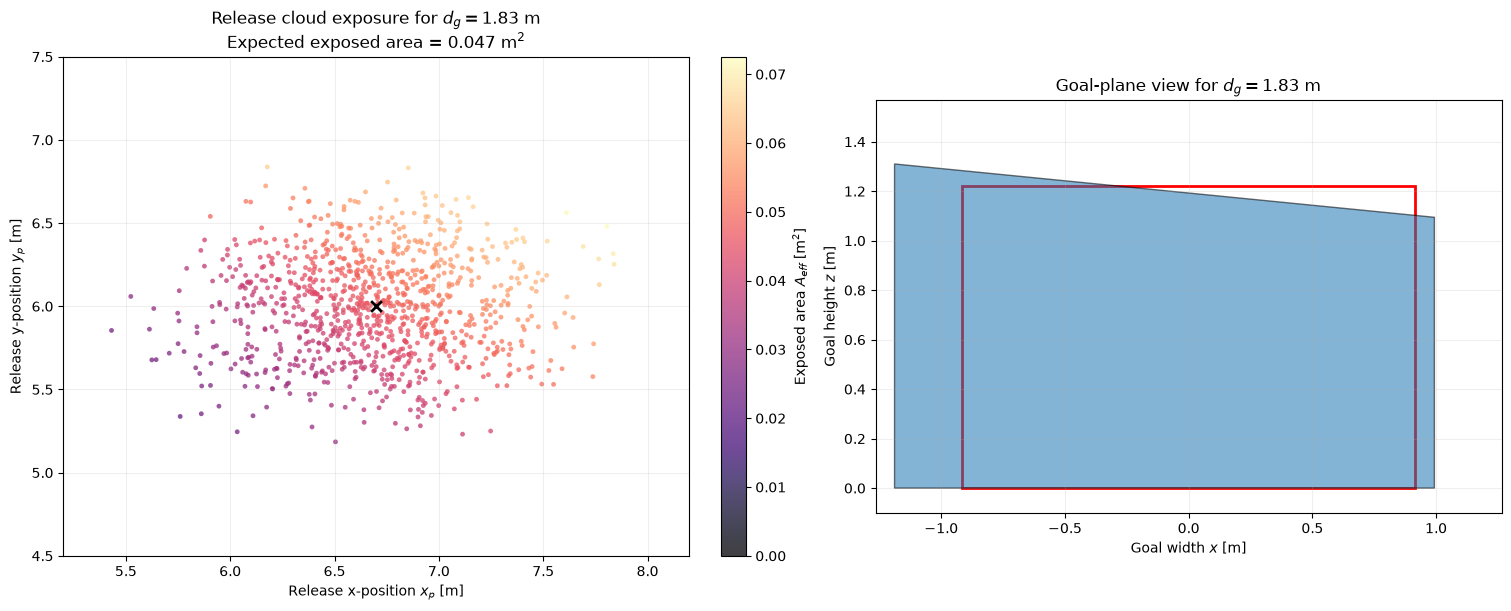

In [53]:
#| label: fig-static-dual-3
#| fig-cap: "Stochastic release analysis for a Face off dot shot $\\vec{p}_0 = (6.7, 6)$ m at $d_g = 1.83$ m. (a) Release cloud exposure on the ice plane. (b) Goal-plane perspective occlusion."
#| out-width: "100%"
#| fig-pos: "H"
#| fig-align: "center"

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(15, 6),
    constrained_layout=True
)

model.plot_release_cloud_exposure(
    p0=(6.7, 6.0),
    ax=ax1
)

model.plot_goal_plane_heatmap(
    p0=(6.7, 6.0),
    ax=ax2
)

plt.show()

writeup about above ^

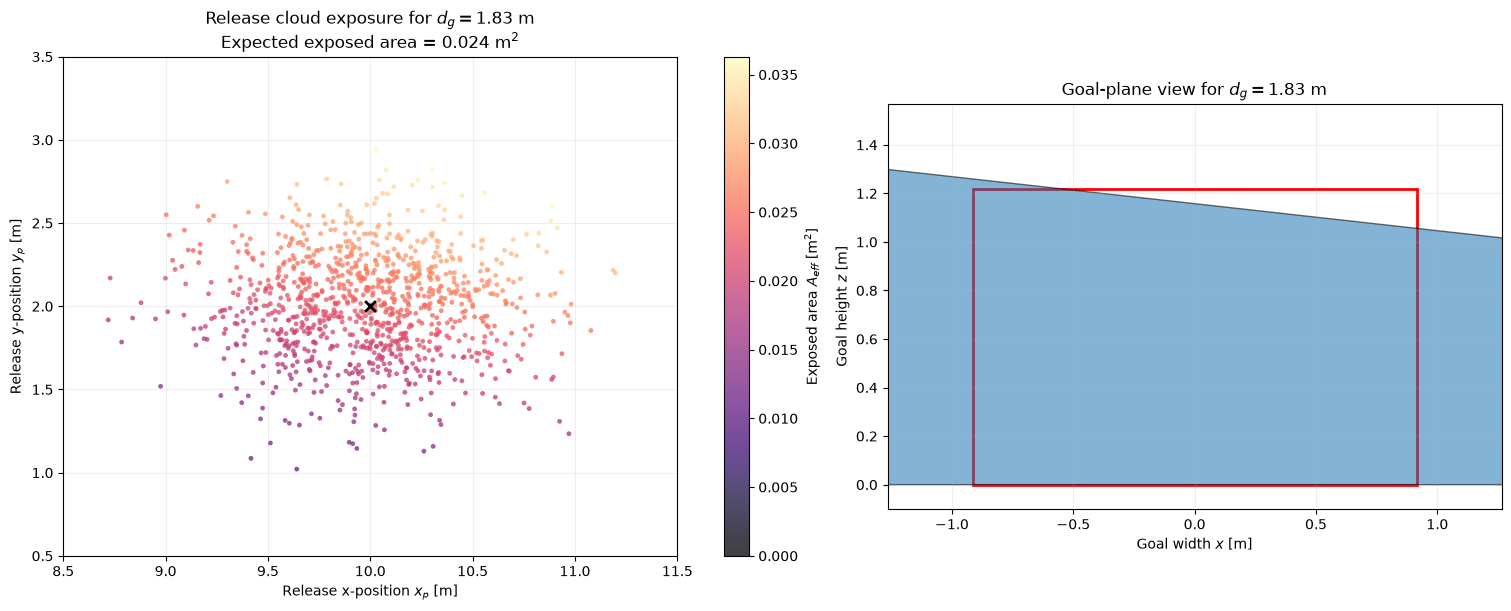

In [54]:
#| label: fig-static-dual-4
#| fig-cap: "Stochastic release analysis for a Goal line shot $\\vec{p}_0 = (10, 2)$ m at $d_g = 1.83$ m. (a) Release cloud exposure on the ice plane. (b) Goal-plane perspective occlusion."
#| out-width: "100%"
#| fig-pos: "H"
#| fig-align: "center"

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(15, 6),
    constrained_layout=True
)

model.plot_release_cloud_exposure(
    p0=(10.0, 2.0),
    ax=ax1
)

model.plot_goal_plane_heatmap(
    p0=(10.0, 2.0),
    ax=ax2
)

plt.show()

writeup about above ^


## Dynamic Pass Feasibility
### recovery windows

### risk curves

### zone wide depth surface

# Discussion
## sub point 1

## sub point 2

## sub point 3

## limitations

# Conclusion
synthesis using questions, framework, and applications of research

\newpage

# References
::: {#refs}
:::